In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [37]:
df=pd.read_csv("data/course_lead_scoring_2026.csv")
df

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1
...,...,...,...,...,...,...,...,...,...
4995,organic_search,education,employed,asia,45834.0,2,2,0.37,1
4996,NaN,technology,employed,north_america,84831.0,2,5,0.51,0
4997,organic_search,finance,employed,asia,53636.0,4,6,0.75,1
4998,referral,technology,employed,africa,69430.0,4,8,0.79,1


In [38]:
df.dtypes

lead_source                  object
industry                     object
employment_status            object
location                     object
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [39]:
numerical=['annual_income','number_of_courses_viewed','interaction_count','lead_score']
categorical=['lead_source','industry','employment_status','location','converted']

In [40]:
df[categorical]=df[categorical].fillna("NA")
df[numerical]=df[numerical].fillna(0)

In [41]:
df.isna().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

##### Question 1
Q: What is the most frequent observation (mode) for the column industry? 

A: **technology**

In [42]:
df['industry'].value_counts()

industry
technology       1173
retail            925
healthcare        840
finance           720
education         639
manufacturing     463
NA                240
Name: count, dtype: int64

##### Question 2

Create the correlation matrix for the numerical features of your dataset. In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

- interaction_count and lead_score

- number_of_courses_viewed and lead_score

- number_of_courses_viewed and interaction_count

- annual_income and interaction_count

Only consider the pairs above when answering this question.

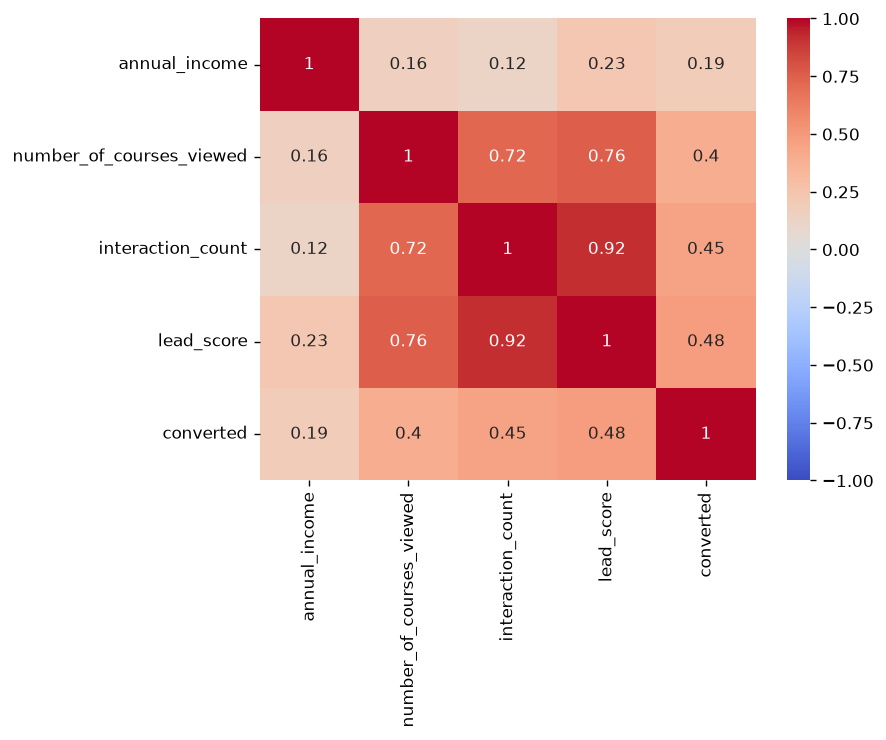

In [43]:
cor=df.corr(numeric_only=True)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [44]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=42
)

len(df_train),len(df_val),len(df_test)


(3000, 1000, 1000)

In [45]:
y_train=df_train.converted.values
y_val=df_val.converted.values
y_test=df_test.converted.values

In [46]:
del df_train['converted']
del df_val['converted']
del df_test['converted']

##### Question 3


Calculate the mutual information score between converted and other categorical variables in the dataset. Use the training set only.

Round the scores to 2 decimals using round(score, 2).
Which of these variables has the biggest mutual information score?


- industry
- location
- lead_source
- employment_status

In [47]:
from sklearn.metrics import mutual_info_score

In [48]:
def mutual_info_converted(series):
    return round(mutual_info_score(series, df_full_train.converted),2)

In [49]:
df_full_train[['lead_source','industry','employment_status','location']].apply(mutual_info_converted)

lead_source          0.03
industry             0.00
employment_status    0.02
location             0.00
dtype: float64

##### Question 4
- Now let's train a logistic regression.

- Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
- Fit the model on the training dataset.
    - To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
    - model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
- Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

In [50]:
from sklearn.feature_extraction import DictVectorizer

In [51]:
from sklearn.feature_extraction import DictVectorizer

dv=DictVectorizer(sparse=False)

train_dicts=df_train[['lead_source','industry','employment_status','location']+numerical].to_dict(orient='records')
X_train=dv.fit_transform(train_dicts)

val_dicts=df_val[['lead_source','industry','employment_status','location']+numerical].to_dict(orient='records')
X_val=dv.transform(val_dicts)

In [52]:
from sklearn.linear_model import LogisticRegression

In [54]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The 

In [55]:
model.coef_[0].round(3) # estos son los w

array([-0.   , -0.001,  0.007, -0.003, -0.008, -0.006, -0.   , -0.003,
       -0.001, -0.002, -0.002, -0.002, -0.001,  0.137,  0.011,  0.   ,
       -0.009,  0.007, -0.014,  0.009, -0.004,  0.   , -0.002, -0.002,
       -0.001, -0.003, -0.004,  0.054])

In [56]:
model.predict(X_train) #hard predictions

array([1, 0, 1, ..., 1, 0, 0], shape=(3000,))

In [58]:
model.predict_proba(X_train) #soft predictions

array([[0.45013615, 0.54986385],
       [0.58507422, 0.41492578],
       [0.35064449, 0.64935551],
       ...,
       [0.37168932, 0.62831068],
       [0.55831429, 0.44168571],
       [0.51455074, 0.48544926]], shape=(3000, 2))

In [59]:
y_pred=model.predict_proba(X_val)[:,1]
y_pred

array([0.61725691, 0.44364108, 0.60433996, 0.64562246, 0.52214159,
       0.77885722, 0.60698076, 0.54481903, 0.76770971, 0.52765495,
       0.75038798, 0.6470054 , 0.56857815, 0.51044645, 0.59921425,
       0.46620745, 0.62786484, 0.69167143, 0.69082953, 0.59101344,
       0.49964695, 0.55590822, 0.65303933, 0.6079306 , 0.7231576 ,
       0.51616805, 0.56141276, 0.57206269, 0.67043904, 0.55599224,
       0.63613322, 0.70337215, 0.45463513, 0.61897288, 0.65250689,
       0.42775649, 0.63943096, 0.62315373, 0.6602988 , 0.51736304,
       0.53774147, 0.76074014, 0.48326071, 0.74151288, 0.63662375,
       0.41194601, 0.45371292, 0.6417333 , 0.43851314, 0.87060984,
       0.72468973, 0.75643941, 0.5296636 , 0.66736678, 0.50444495,
       0.57644782, 0.72318139, 0.72497254, 0.6507741 , 0.628958  ,
       0.7217776 , 0.59231588, 0.70824617, 0.61451576, 0.49691434,
       0.74445314, 0.52773381, 0.61402574, 0.55979831, 0.59024431,
       0.69368703, 0.72962242, 0.76111566, 0.60744404, 0.52501

In [65]:
converted_decision=y_pred>=0.5

In [66]:
converted_decision.astype(int)

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,

In [69]:
round((y_val==converted_decision).mean(),2)

np.float64(0.64)

##### Question 5
- Let's find the least useful feature using the feature elimination technique.
- Train a model using the same features and parameters as in Q4 (without rounding).
- Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
- For each feature, calculate the difference between the original accuracy and the accuracy without the feature.


Which of following feature has the smallest difference?

- 'lead_source'
- 'number_of_courses_viewed'
- 'interaction_count'

In [73]:
features = ['lead_source', 'industry', 'employment_status', 'location'] + numerical

dv = DictVectorizer(sparse=False)
train_dicts = df_train[features].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[features].to_dict(orient='records')
X_val = dv.transform(val_dicts)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]
orig_accuracy = (y_val == (y_pred >= 0.5)).mean()
print(f"Accuracy original (todas las características): {orig_accuracy:.6f}\n")

diffs = []

for feature in features:
    features_sub = [f for f in features if f != feature] # esta linea crea una lista de características sin la característica actual

    dv_sub=DictVectorizer(sparse=False)
    X_train_sub=dv_sub.fit_transform(df_train[features_sub].to_dict(orient='records'))
    X_val_sub=dv_sub.transform(df_val[features_sub].to_dict(orient='records'))
    
    model_sub = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model_sub.fit(X_train_sub,y_train)
    
    y_pred_sub=model_sub.predict_proba(X_val_sub)[:,1]
    acc_sub=(y_val==(y_pred_sub>=0.5)).mean()
    
    diff = orig_accuracy-acc_sub
    diffs[feature]=diff
    
    print(f"Sin '{feature}': accuracy = {acc_sub:.6f}, diferencia = {diff:+.6f} (abs: {abs(diff):.6f})")

options = ['lead_source', 'number_of_courses_viewed', 'interaction_count']
options_diffs = {f: diffs[f] for f in options if f in diffs}
least_useful = min(options_diffs, key=lambda f: abs(options_diffs[f]))

print(f"\nEntre las opciones {options}:")
print(f"La característica con la menor diferencia es: '{least_useful}' (diferencia = {diffs[least_useful]:+.6f})")

Accuracy original (todas las características): 0.645000

Sin 'lead_source': accuracy = 0.642000, diferencia = +0.003000 (abs: 0.003000)
Sin 'industry': accuracy = 0.645000, diferencia = +0.000000 (abs: 0.000000)
Sin 'employment_status': accuracy = 0.645000, diferencia = +0.000000 (abs: 0.000000)
Sin 'location': accuracy = 0.645000, diferencia = +0.000000 (abs: 0.000000)
Sin 'annual_income': accuracy = 0.724000, diferencia = -0.079000 (abs: 0.079000)
Sin 'number_of_courses_viewed': accuracy = 0.643000, diferencia = +0.002000 (abs: 0.002000)
Sin 'interaction_count': accuracy = 0.601000, diferencia = +0.044000 (abs: 0.044000)
Sin 'lead_score': accuracy = 0.644000, diferencia = +0.001000 (abs: 0.001000)

Entre las opciones ['lead_source', 'number_of_courses_viewed', 'interaction_count']:
La característica con la menor diferencia es: 'number_of_courses_viewed' (diferencia = +0.002000)


##### Question 6
- Now let's train a regularized logistic regression.
- Let's try the following values of the parameter C: [0.000001, 0.00001, 0.0001, 0.001].
- Train models using all the features as in Q4.
- Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

Which of these C leads to the best accuracy on the validation set?

- 0.000001
- 0.00001
- 0.0001
- 0.001

In [ ]:
C_values = [0.000001, 0.00001, 0.0001, 0.001]

scores = []

for C in C_values:
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict_proba(X_val)[:, 1]
    acc = (y_val == (y_pred >= 0.5)).mean()
    acc_round = round(acc, 3)
    scores[C] = acc_round
    
    print(f"C = {C:<8} -> accuracy = {acc:.6f} | round = {acc_round}")

best_C = max(scores, key=scores.get)
print(f"\nEl valor de C que da la mejor precision en el conjunto de validacion es: {best_C} con accuracy = {scores[best_C]}")


C = 1e-06    -> accuracy = 0.598000 | round = 0.598
C = 1e-05    -> accuracy = 0.598000 | round = 0.598
C = 0.0001   -> accuracy = 0.613000 | round = 0.613
C = 0.001    -> accuracy = 0.645000 | round = 0.645

El valor de C que da la mejor precision en el conjunto de validacion es: 0.001 con accuracy = 0.645
